In [1]:
import json
from pathlib import Path
import sys
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import pickle

sys.path.append(os.path.abspath("../"))
from simulators.CA_modified import CellularAutomaton_humidity_age #true (hard) CA
from simulators.model_solver_real_data import SoftFireCA, SoftFireCA_wind, fit_no_wind, fit_wind, plot_results_no_wind, plot_results_wind, combined_loss, masked_mse #soft CA
from simulators.metrics import FireMetrics #compute metrics

In [2]:
temp = np.load("../data/backtest/fire_example_45/2022-07-12_temperature.npy")
wind_dir = np.load("../data/backtest/fire_example_45/2022-07-12_wind_direction.npy")
wind_val = np.load("../data/backtest/fire_example_45/2022-07-12_wind_val.npy")
humidity = np.load("../data/backtest/fire_example_45/2022-07-13_humidity.npy")
height_grid = np.load("../data/backtest/fire_example_45/altitude.npy")
ground = np.load("../data/backtest/fire_example_45/ground_matrix.npy", allow_pickle=True)
fire_spread = np.load("../data/backtest/fire_example_45/fire_spread.npy")

In [3]:
default_age_grid = np.ones_like(temp)*50
wind_speed = wind_val
wind_grid = (wind_speed -wind_speed.min())/(wind_speed.max() -wind_speed.min())
forest = np.isin(ground, ["water", "bay", "sand", "dune", "wetland", "military" ]) #{model.gamma.item():.3f}places that cant burn or are protected
forest = 1- forest.astype(int)
if humidity.min() != humidity.max():
    default_moisture_grid = (humidity -humidity.min())/(humidity.max() -humidity.min())
else:
    default_moisture_grid = 0.5 * np.ones_like(humidity)
wind_dir_rad = np.deg2rad(wind_dir + 180)

In [4]:
LAND_PARAMS = {
    #                 moisture  age
    "bay":           (0.95,     0),
    "beach":         (0.30,     0),
    "brownfield":    (0.10,     0),
    "cemetery":      (0.35,    10),
    "coastline":     (0.70,     2),
    "dune":          (0.15,     3),
    "empty":         (0.10,     0),
    "forest":        (0.50,    40),
    "grass":         (0.30,     5),
    "grassland":     (0.30,     8),
    "industrial":    (0.05,     0),
    "meadow":        (0.45,    10),
    "military":      (0.20,     5),
    "residential":   (0.20,     5),
    "sand":          (0.10,     0),
    "scrub":         (0.25,    15),
    "tree":          (0.45,    25),
    "water":         (1.00,     0),
    "wetland":       (0.90,     5),
}

In [5]:
def ground_to_grids(ground, land_params=LAND_PARAMS):
    moisture_vals = np.array([v[0] for v in land_params.values()], dtype=np.float32)
    age_vals      = np.array([v[1] for v in land_params.values()], dtype=np.float32)
    keys          = list(land_params.keys())

    key_to_idx = {k: i for i, k in enumerate(keys)}
    idx_grid   = np.vectorize(lambda x: key_to_idx.get(x, 0))(ground)

    return moisture_vals[idx_grid], age_vals[idx_grid]

moisture_grid, age_grid = ground_to_grids(ground)

In [6]:
ignition_point = [fire_spread[0].argmax()//fire_spread[0].shape[0],fire_spread[0].argmax()%fire_spread[0].shape[0]]
ignition_value = fire_spread[0][ignition_point[0], ignition_point[1]]
print (ignition_point, ignition_value)

FM=FireMetrics(fire_spread, fire_spread)
arrival_time = FM.arrival_time_G
arrival_time[np.isinf(arrival_time)] = -1

[np.int64(21), np.int64(28)] 7.841371225840634e-05


In [7]:
def arrival_to_sequence(arrival, n_steps):
    if isinstance(arrival, torch.Tensor):
        arrival = arrival.detach().cpu().numpy()
    else:
        arrival = np.array(arrival)
 
    H, W = arrival.shape
    sequence = -np.zeros((n_steps, H, W), dtype=np.float32)
 
    for t in range(1, n_steps):
        burned = (arrival <= t) & (arrival > t-1)
        sequence[t] = sequence[t-1] + burned.astype(np.float32)
 
    return sequence

## Without wind direction

In [2]:
def get_metrics_for_substeps(max_substeps, time):

    fire_data = {"ignition_point": ignition_point,
                "ignition_value": ignition_value,
                "arrival_time":   arrival_time,
                "wind_grid":     wind_grid,
                }
    
    results= []

    for i in range(1, max_substeps+1):
        model = SoftFireCA(
            height_grid, age_grid, moisture_grid,
            alpha_init=0.8, beta_init=0.8, gamma_init=0.8, burn_mask=forest
        )
        print(f"computing for {i} substeps")
        history = fit_no_wind(model, [fire_data], n_steps=len(fire_spread), n_substeps=i, n_epochs=100, lr=0.08, verbose=False)

        print(f"\nRecovered:  α={model.alpha.item():.3f}  "
              f"β={model.beta.item():.3f}  γ={model.gamma.item():.3f} with final loss {history["loss"][-1]}")

        arrival_prediction = model.forward(ignition_point, ignition_value, wind_grid, len(fire_spread), i)
        
        prediction = arrival_to_sequence(arrival_prediction, len(fire_spread))
        FM = FireMetrics(prediction, fire_spread)
        full_dic = FM.all_shape_metrics(time, time) | FM.all_spread_metrics()
        results.append(full_dic)

        #Graph
        arrival_prediction = arrival_prediction.detach().cpu().numpy()
        arrival_prediction[arrival_prediction > len(fire_spread)-1] = -1
        arrival_prediction = np.round(arrival_prediction)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(arrival_prediction, cmap='hot', interpolation='nearest')
        plt.title("Prediction")
        plt.colorbar()

        plt.subplot(1, 2, 2)
        plt.imshow(arrival_time, cmap='hot', interpolation='nearest')
        plt.title("Ground_truth")
        plt.colorbar()

        plt.tight_layout()
        plt.show()

    return results

In [9]:
all_results = get_metrics_for_substeps(15, len(fire_spread)-1)

computing for 1 substeps


AttributeError: 'SoftFireCA' object has no attribute 'log_delta'

## With wind direction

In [ ]:
def get_metrics_for_substeps_wind(max_substeps, time):

    fire_data = {"ignition_point": ignition_point,
                "ignition_value": ignition_value,
                "arrival_time":   arrival_time,
                "wind_speed":     wind_speed,
                "wind_dir": wind_dir_rad
                }
    
    results= []

    for i in range(1, max_substeps+1):
        model = SoftFireCA_wind(
        height_grid, age_grid, moisture_grid,
        alpha_init=0.8, beta_init=0.8, gamma_init=0.8, delta_init=0.0001, burn_mask=forest
    )
        print(f"computing for {i} substeps")
        history = fit_no_wind(model, [fire_data], n_steps=len(fire_spread), n_substeps=i,n_epochs=100, lr=0.08, verbose=False)

        print(f"\nRecovered:  α={model.alpha.item():.3f}  "
              f"β={model.beta.item():.3f}  γ={model.gamma.item():.3f} δ={model.delta.item():.3f} with final loss {history["loss"][-1]}")

        arrival_prediction = model.forward(ignition_point, ignition_value, wind_speed, wind_dir, len(fire_spread), i)
        
        prediction = arrival_to_sequence(arrival_prediction, len(fire_spread))
        FM = FireMetrics(prediction, fire_spread)
        full_dic = FM.all_shape_metrics(time, time) | FM.all_spread_metrics()
        results.append(full_dic)

        #Graph
        arrival_prediction = arrival_prediction.detach().cpu().numpy()
        arrival_prediction[arrival_prediction > len(fire_spread)-1] = -1
        arrival_prediction = np.round(arrival_prediction)

        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(arrival_prediction, cmap='hot', interpolation='nearest')
        plt.title("Prediction")
        plt.colorbar()

        plt.subplot(1, 2, 2)
        plt.imshow(arrival_time, cmap='hot', interpolation='nearest')
        plt.title("Ground_truth")
        plt.colorbar()

        plt.tight_layout()
        plt.show()

    return results

computing for 1 substeps

Recovered:  α=0.800  β=0.015  γ=0.014 δ=0.000 with final loss 0.28589481115341187


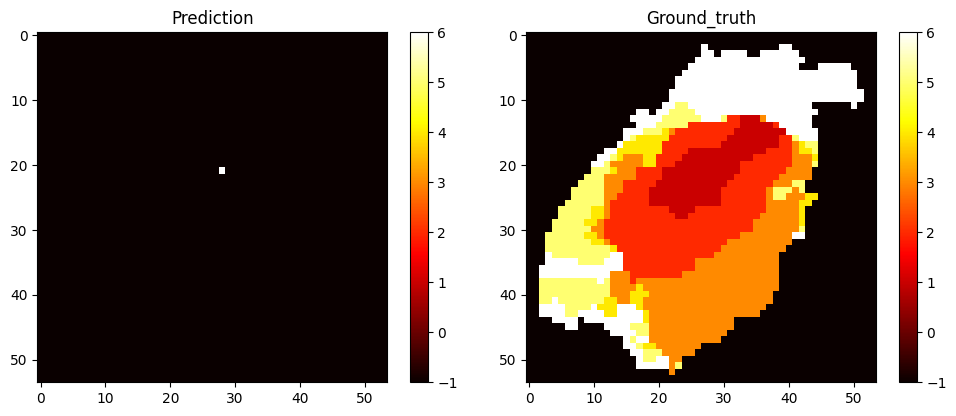

computing for 2 substeps

Recovered:  α=0.019  β=0.054  γ=0.045 δ=0.003 with final loss 0.18864218890666962


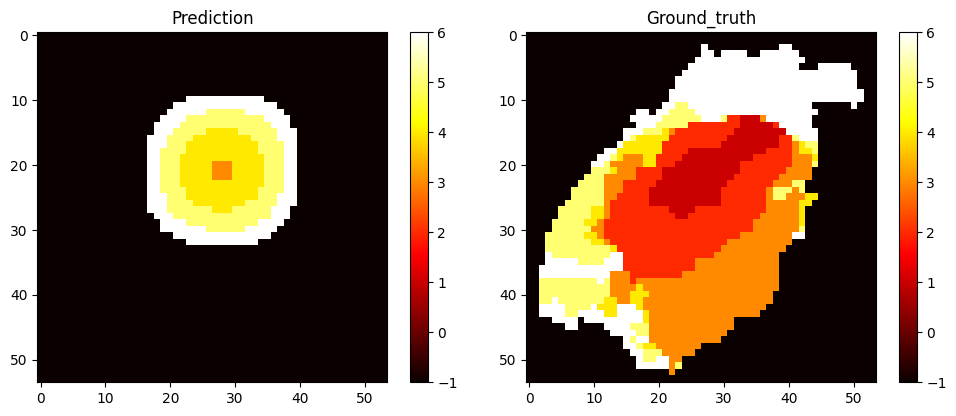

computing for 3 substeps

Recovered:  α=0.032  β=0.086  γ=0.087 δ=0.020 with final loss 0.09530803561210632


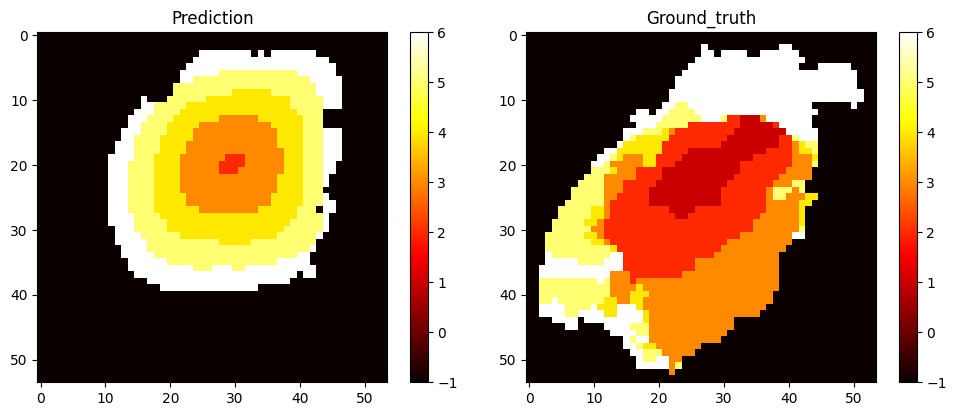

computing for 4 substeps

Recovered:  α=0.051  β=0.138  γ=0.221 δ=0.020 with final loss 0.05160689726471901


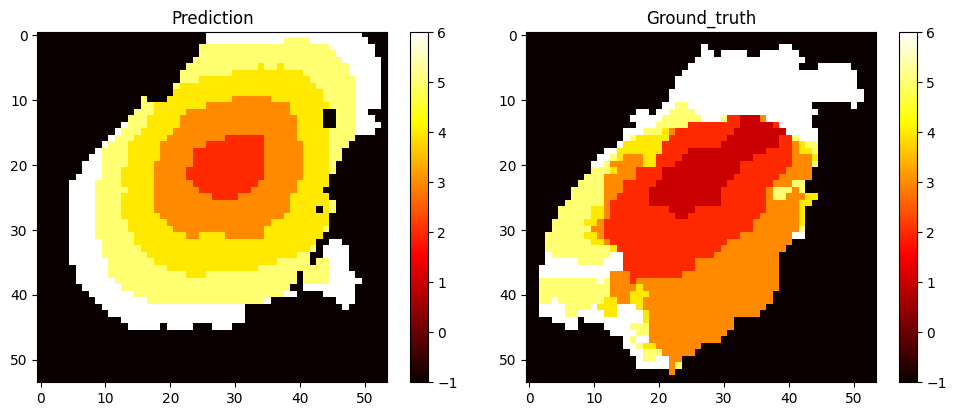

computing for 5 substeps

Recovered:  α=0.057  β=0.167  γ=0.684 δ=0.020 with final loss 0.03458274155855179


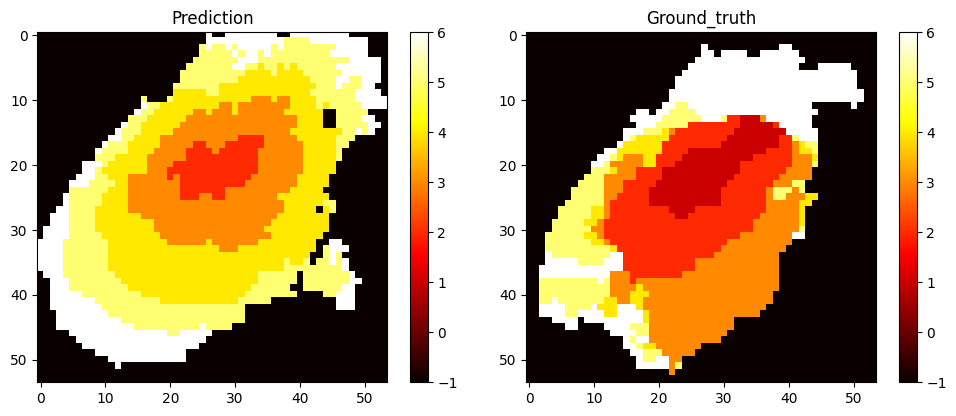

computing for 6 substeps

Recovered:  α=0.066  β=0.244  γ=1.019 δ=0.019 with final loss 0.03147447854280472


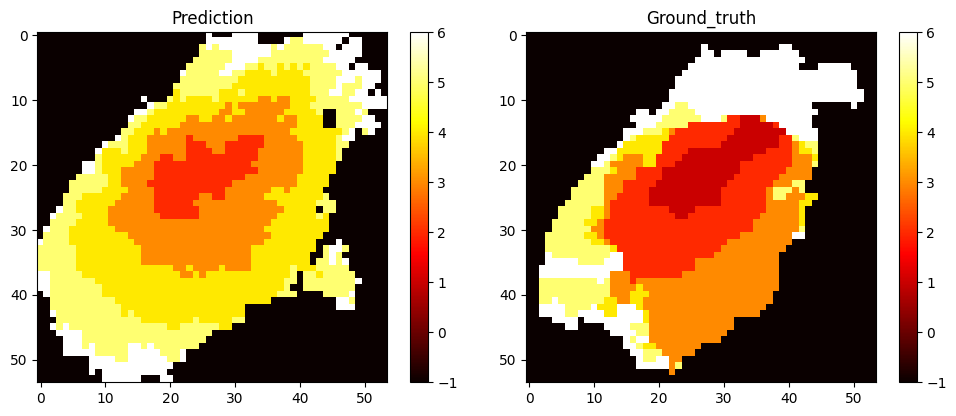

computing for 7 substeps

Recovered:  α=0.073  β=1.185  γ=0.885 δ=0.019 with final loss 0.030917977914214134


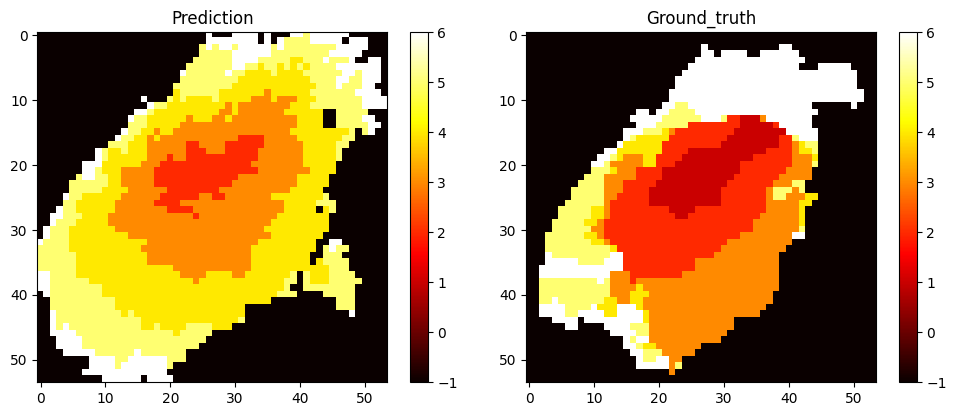

computing for 8 substeps

Recovered:  α=0.072  β=1.944  γ=0.783 δ=0.019 with final loss 0.030687853693962097


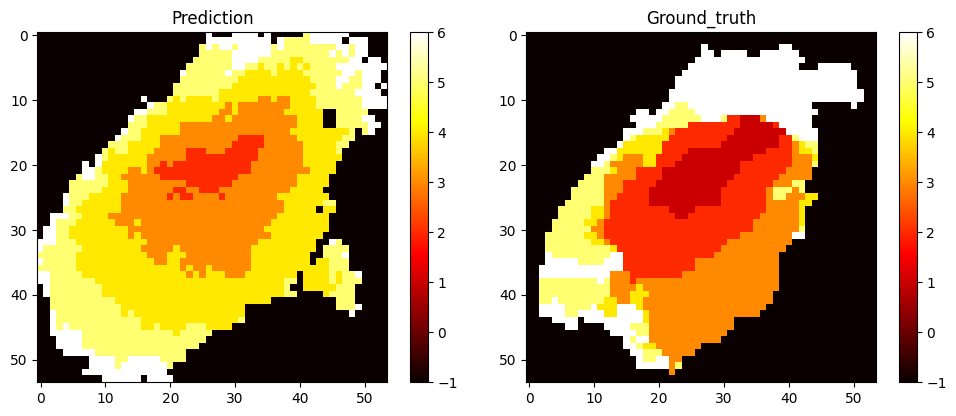

computing for 9 substeps

Recovered:  α=0.070  β=2.388  γ=0.759 δ=0.017 with final loss 0.03111509047448635


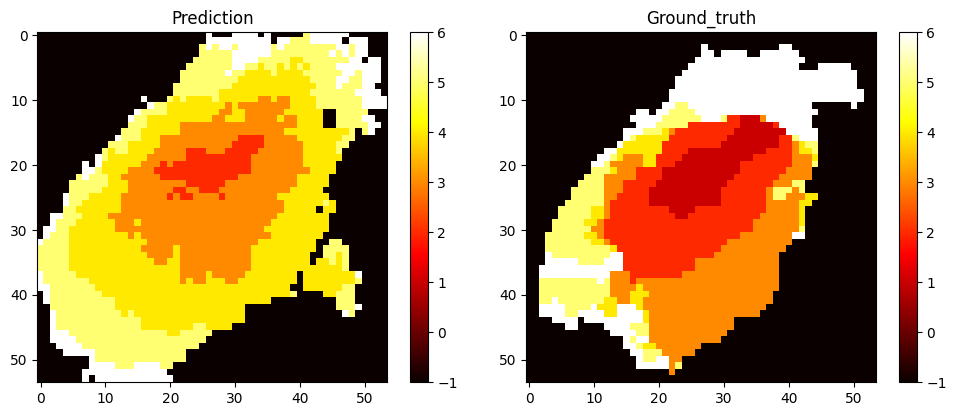

computing for 10 substeps

Recovered:  α=0.093  β=2.770  γ=0.785 δ=0.017 with final loss 0.03145139664411545


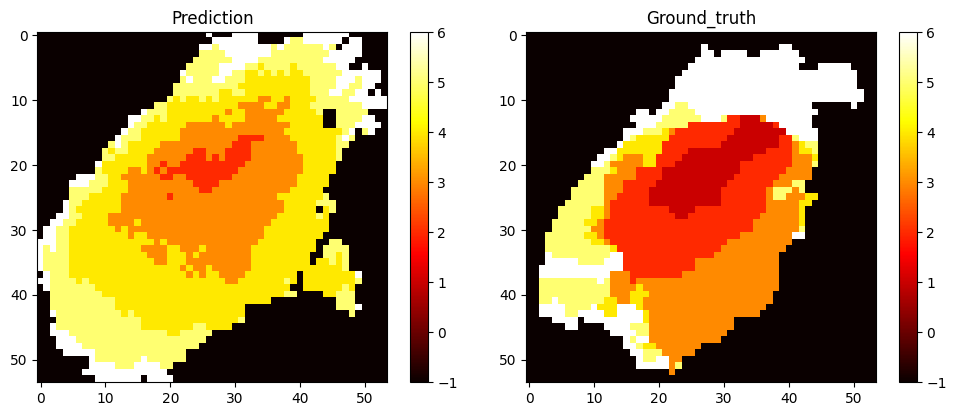

computing for 11 substeps

Recovered:  α=nan  β=nan  γ=nan δ=nan with final loss nan


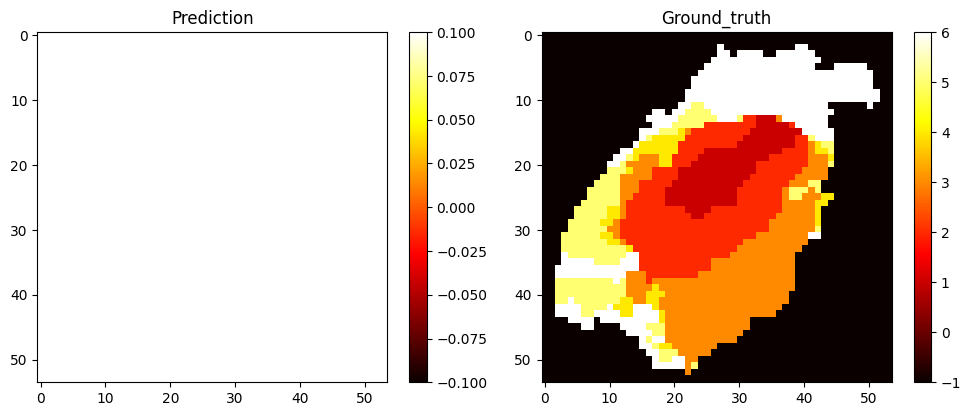

computing for 12 substeps

Recovered:  α=nan  β=nan  γ=nan δ=nan with final loss nan


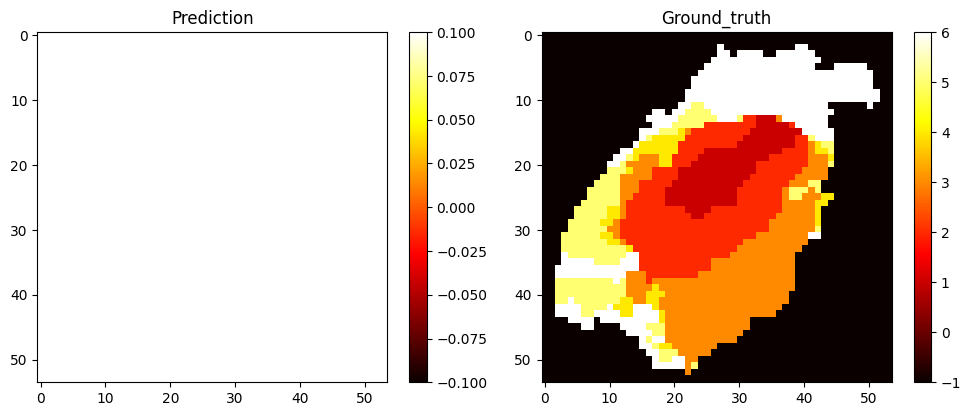

computing for 13 substeps

Recovered:  α=nan  β=nan  γ=nan δ=nan with final loss nan


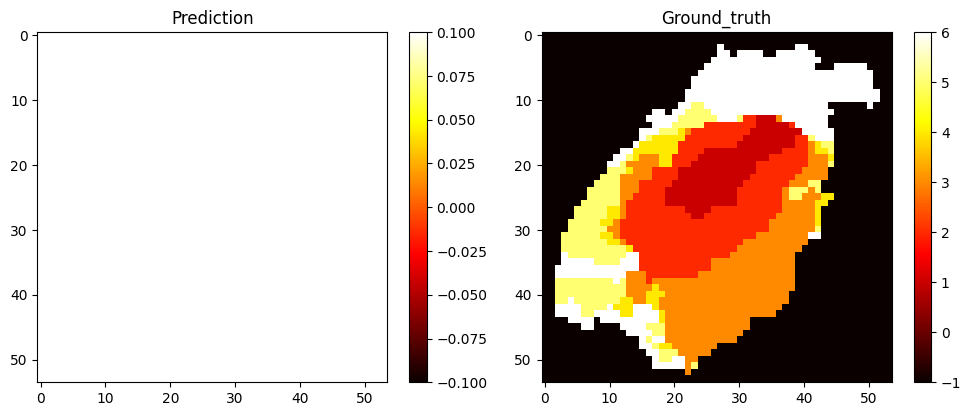

computing for 14 substeps


KeyboardInterrupt: 

In [ ]:
all_results = get_metrics_for_substeps_wind(10, len(fire_spread)-1)

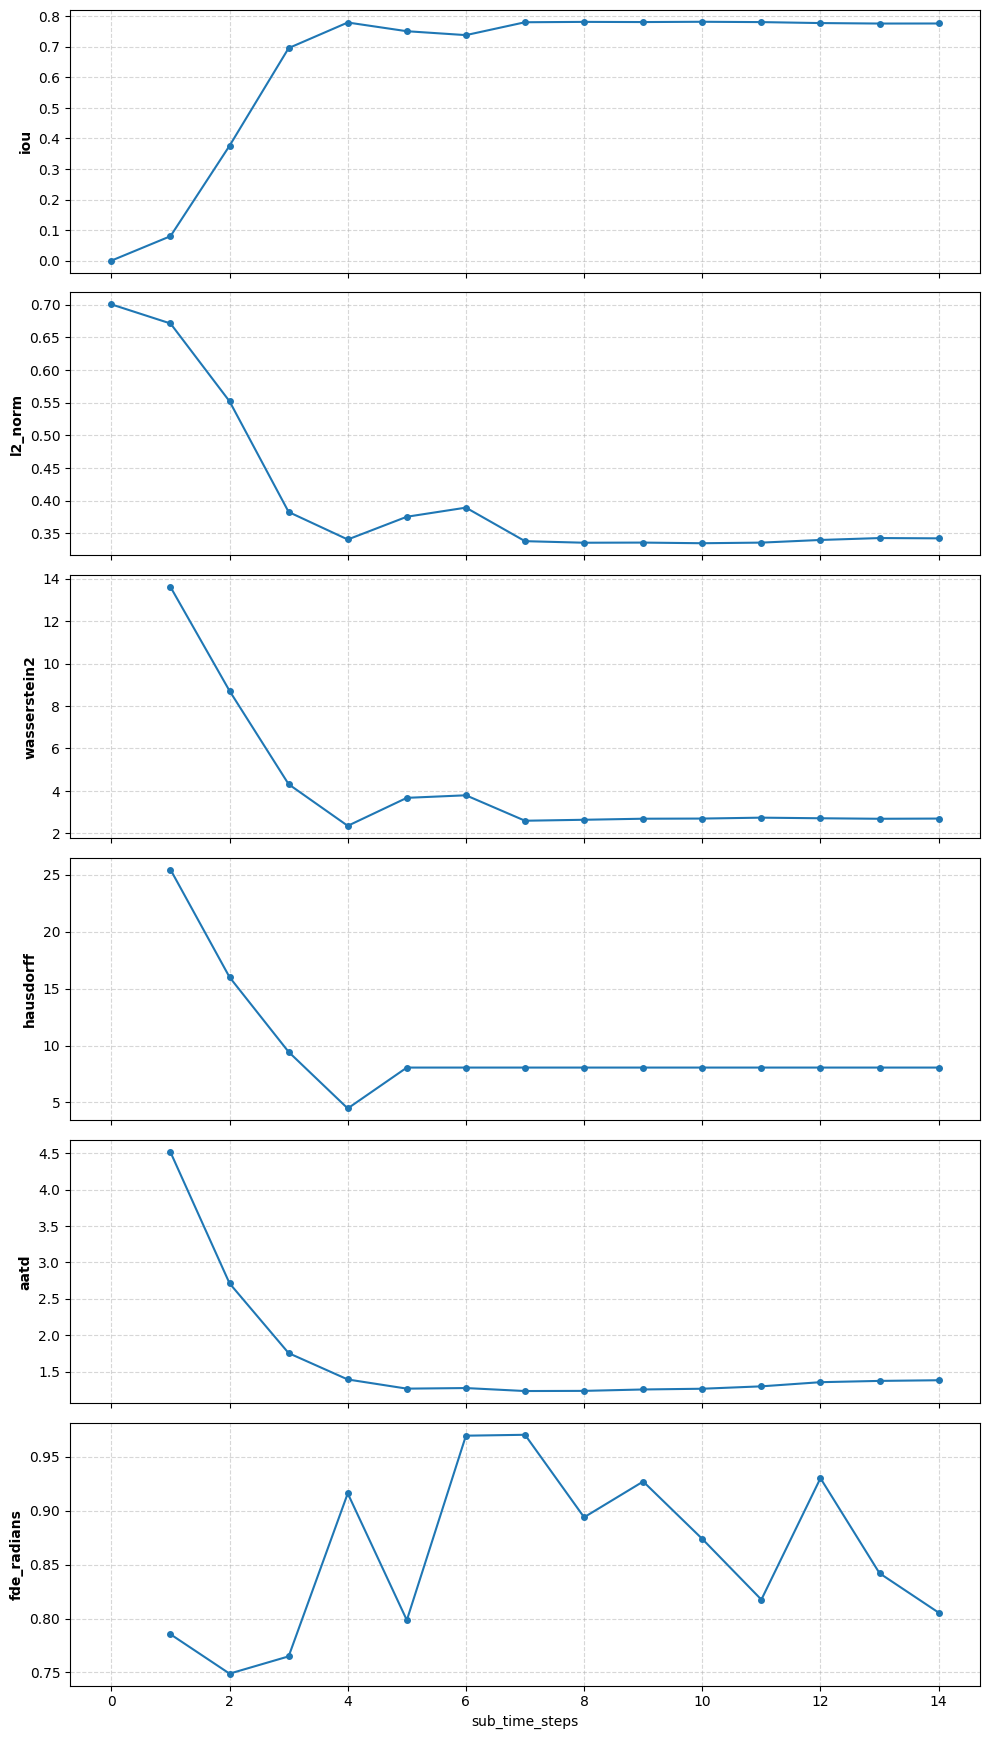

In [ ]:
metrics = list(all_results[0].keys())
time_steps = np.arange(len(all_results))

fig, axes = plt.subplots(len(metrics)-1, 1, figsize=(10, 2.5 * len(metrics)), sharex=True)

for ax, metric in zip(axes, metrics[:-1]):
    values = np.array([step[metric] for step in all_results], dtype=float)
    ax.plot(time_steps, values, marker='o', markersize=4, linestyle='-', color='tab:blue')
    ax.set_ylabel(metric, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.xlabel("sub_time_steps")
plt.tight_layout()
plt.show()